# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Eng7ouda06/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

Setup




In [1]:
import os, subprocess, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier as HGB
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
URL = "https://github.com/Eng7ouda06/flyrank-ml-internship.git"
if not os.path.exists("data/raw/content_refresh_anonymized.csv"):
    if not os.path.exists("flyrank-ml-internship"):
        subprocess.run(["git", "clone", "-q", URL], check=True)
    os.chdir("flyrank-ml-internship")
os.makedirs("work/outputs", exist_ok=True); os.makedirs("work/figures", exist_ok=True)
SEED = 42

## 1. Question

*The research question and the decision it supports.*

**Which already-visible pages under-capture clicks compared with peers at the same ranking position?**

Decision supported: which pages a content team should review first (metadata, content, or monitoring), when review capacity is limited.


In [2]:
MIN_IMPR = 100      # min impressions in each 30-day window (CTR is noisy below this)
MAX_POS = 50        # keep pages ranking within position 50
UNDER_Q = 1/3       # under-capture = bottom third of CTR within its position bucket
print("Question: rank pages by likelihood of under-capturing clicks for their position")

Question: rank pages by likelihood of under-capturing clicks for their position


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [3]:
raw = pd.read_csv("data/raw/content_refresh_anonymized.csv")
d = raw[(raw.impressions_last_30d >= MIN_IMPR) & (raw.impressions_prev_30d >= MIN_IMPR) & (raw.avg_position <= MAX_POS)].copy()
print(f"raw rows: {len(raw):,} | eligible: {len(d):,} | clients: {d.client_id.nunique()}")

raw rows: 30,000 | eligible: 15,237 | clients: 29


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

FlyRank **anonymized starter release**, one table (`content_refresh_anonymized.csv`): hashed content/client IDs, no client names, domains, URLs, or queries. Kept pages with ≥100 impressions in both the last and previous 30 days and average position ≤ 50. Excluded the rest because CTR is too noisy at low volume. This is the starter slice, not the full warehouse.

In [5]:
d["pos_bucket"] = pd.cut(d.avg_position, [0, 3, 10, 20, 50], labels=False)
d["ctr_last"] = d.clicks_last_30d / d.impressions_last_30d
d["ctr_prev"] = d.clicks_prev_30d / d.impressions_prev_30d
d["y"] = (d.ctr_last <= d.groupby("pos_bucket").ctr_last.transform(lambda s: s.quantile(UNDER_Q))).astype(int)
d["log_impr_prev"] = np.log1p(d.impressions_prev_30d)
d["ctr_prev_rank"] = d.groupby("pos_bucket").ctr_prev.rank(pct=True)
for c in ["content_type", "main_intent", "competition_level"]:
    d[c] = d[c].astype("category").cat.codes
F = ["log_impr_prev","ctr_prev","ctr_prev_rank","avg_position","search_volume","competition","cpc",
     "word_count","content_age_days","days_since_last_update","content_type","main_intent","competition_level"]
BANNED = ["ctr","clicks_90d","sessions_90d","trend_pct","trend_direction","clicks_last_30d","sessions_last_30d","ctr_last"]
assert not set(F) & set(BANNED), "leakage: label-window feature found"
print("leakage check passed | base rate:", round(d.y.mean(), 3))

leakage check passed | base rate: 0.374


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Model and baseline scored on the same out-of-fold predictions, same rows.

In [6]:
X, y, g = d[F], d.y.values, d.client_id.values
oof = np.zeros(len(d)); base = (1 - d.ctr_prev_rank).values
for tr, te in GroupKFold(5).split(X, y, g):
    m = HGB(max_iter=200, learning_rate=0.05, random_state=SEED).fit(X.iloc[tr], y[tr])
    oof[te] = m.predict_proba(X.iloc[te])[:, 1]
def met(s):
    k = int(.05 * len(s)); top = np.argsort(-s)[:k]
    return {"ROC AUC": roc_auc_score(y, s), "Avg precision": average_precision_score(y, s), "Precision@5%": y[top].mean()}
res = pd.DataFrame({"baseline (prior CTR)": met(base), "model (HGB)": met(oof)}).round(3)
res

,baseline (prior CTR),model (HGB)
ROC AUC,0.735,0.820
Avg precision,0.586,0.708
Precision@5%,0.619,0.875


## 5. Limitations

*What this work cannot claim.*

- Starter slice, not the full warehouse; results may differ on the full release.
- Average position is a 90-day figure that partly overlaps the label window, so the split is directional, not a clean time split.
- The label is relative (peer bottom third), so it always flags some pages.
- Results are observed associations and decision-support only. No causal claim about metadata changes and nothing about Google's algorithm.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Top 10% of pages by out-of-fold score, given a first action by rule: metadata review (top-10 position, high impressions) → refresh review (stale >180 days) → content depth review (bottom-quartile word count) → monitor.

In [7]:
d["score"] = oof
top = d.nlargest(int(.1 * len(d)), "score").copy()
wc25, i50 = d.word_count.quantile(.25), d.impressions_prev_30d.median()
def act(r):
    if r.avg_position <= 10 and r.impressions_prev_30d >= i50: return "metadata_review"
    if r.days_since_last_update > 180: return "refresh_review"
    if r.word_count < wc25: return "content_depth_review"
    return "monitor"
top["action"] = top.apply(act, axis=1)
plan = top.groupby("action").agg(pages=("y", "size"), observed_under_capture=("y", "mean")).round(3).sort_values("pages", ascending=False)
print(f"top-10% under-capture rate: {top.y.mean():.3f} vs overall {d.y.mean():.3f}")
plan

top-10% under-capture rate: 0.812 vs overall 0.374


,pages,observed_under_capture
action,,
monitor,1094,0.803
content_depth_review,233,0.794
metadata_review,195,0.882
refresh_review,1,1.000


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

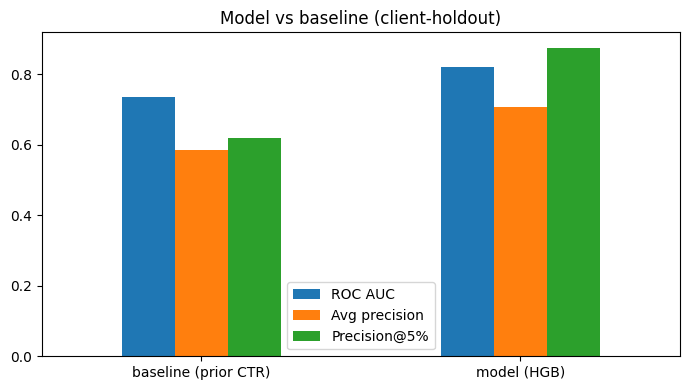

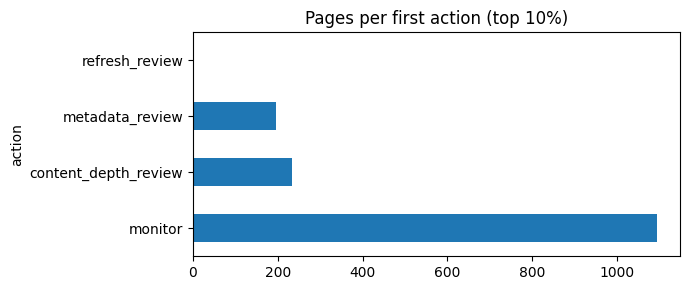

saved figures + metrics


In [8]:
ax = res.T.plot.bar(figsize=(7, 4), rot=0); ax.set_title("Model vs baseline (client-holdout)")
plt.tight_layout(); plt.savefig("work/figures/model_vs_baseline.png", dpi=150); plt.show()
ax = plan.pages.plot.barh(figsize=(7, 3)); ax.set_title("Pages per first action (top 10%)")
plt.tight_layout(); plt.savefig("work/figures/action_mix.png", dpi=150); plt.show()
json.dump({"rows_eligible": len(d), "base_rate": round(d.y.mean(), 3), "metrics": res.to_dict(), "plan": plan.to_dict(), "seed": SEED, "split": "GroupKFold(5) by client_id"},
          open("work/outputs/capstone_metrics_colab.json", "w"), indent=1)
print("saved figures + metrics")

## ML-12 — Closing

**5-minute demo outline**
1. Problem: limited review time, which pages first? (30s)
2. Label: bottom-third CTR within position bucket (45s)
3. Leakage rules and client-holdout split (60s)
4. Model vs baseline table (60s)
5. Top-10% action table and what to do Monday (60s)
6. Limits: starter slice, observed not causal (45s)

**Social post**
Built a model that ranks pages likely to under-capture clicks for their ranking position. Validated on held-out clients and beat a prior-CTR rule. Observed and predictive, not causal. Built on the FlyRank ML Internship dataset.

**Employer-facing summary**
I built an end-to-end ML workflow on real search data, from label design and leakage control to client-grouped validation against a baseline. The model ranks pages for review and maps each to an action. I deployed the results as a public research paper with honest limits.